<a href="https://colab.research.google.com/github/VenkataAkashGurram/VenkataAkashGurram_INFO5731_Spring2026/blob/main/Gurram_Venkata_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [21]:
# ─────────────────────────────────────────────────────────────────────
# QUESTION 1 – N-gram Analysis (from scratch)
# ─────────────────────────────────────────────────────────────────────
import pandas as pd
import re
import string
from collections import defaultdict

# ── Load dataset (100 reviews) ──────────────────────────────────────
df = pd.read_csv('/content/imdb_reviews_cleaned (1).csv').head(100)
reviews = df['review_text'].fillna('').tolist()

# ── Helper: tokenize a sentence ─────────────────────────────────────
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your',
    'yours','yourself','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs',
    'themselves','what','which','who','whom','this','that','these',
    'those','am','is','are','was','were','be','been','being','have',
    'has','had','having','do','does','did','doing','a','an','the',
    'and','but','if','or','because','as','until','while','of','at',
    'by','for','with','about','against','between','into','through',
    'during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then',
    'once','here','there','when','where','why','how','all','both',
    'each','few','more','most','other','some','such','no','nor','not',
    'only','own','same','so','than','too','very','s','t','can','will',
    'just','don','should','now','d','ll','m','o','re','ve','y','ain',
    'aren','couldn','didn','doesn','hadn','hasn','haven','isn','ma',
    'mightn','mustn','needn','shan','shouldn','wasn','weren','won','wouldn'
}

def tokenize(text):
    """Lowercase, strip punctuation, remove stopwords."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

# ── Tokenize all reviews ────────────────────────────────────────────
tokenized_reviews = [tokenize(r) for r in reviews]
all_tokens = [t for tokens in tokenized_reviews for t in tokens]
print(f"Total tokens across 100 reviews: {len(all_tokens)}")
print(f"Unique tokens: {len(set(all_tokens))}")

# ────────────────────────────────────────────────────────────────────
# (1a) N-gram frequency counter (from scratch)
# ────────────────────────────────────────────────────────────────────
def build_ngrams(token_list, n):
    """Generate all n-grams from a flat token list."""
    ngrams = defaultdict(int)
    for i in range(len(token_list) - n + 1):
        gram = tuple(token_list[i:i + n])
        ngrams[gram] += 1
    return ngrams

trigram_freq = build_ngrams(all_tokens, 3)
bigram_freq  = build_ngrams(all_tokens, 2)
unigram_freq = build_ngrams(all_tokens, 1)   # needed for bigram probability

# Display top 20 trigrams
top_trigrams = sorted(trigram_freq.items(), key=lambda x: x[1], reverse=True)[:20]
print("\n── Top 20 Trigrams ─────────────────────────────────────")
print(f"{'Trigram':<40} {'Count':>6}")
print("-" * 48)
for gram, cnt in top_trigrams:
    print(f"{' '.join(gram):<40} {cnt:>6}")

# Display top 20 bigrams
top_bigrams = sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True)[:20]
print("\n── Top 20 Bigrams ──────────────────────────────────────")
print(f"{'Bigram':<30} {'Count':>6}")
print("-" * 38)
for gram, cnt in top_bigrams:
    print(f"{' '.join(gram):<30} {cnt:>6}")
# ────────────────────────────────────────────────────────────────────
# (1b) Bigram probability: P(w2 | w1) = count(w1 w2) / count(w1)
# ────────────────────────────────────────────────────────────────────
def compute_bigram_probabilities(bigram_freq, unigram_freq):
    """Return dict: (w1, w2) -> P(w2|w1)."""
    probs = {}
    for (w1, w2), cnt in bigram_freq.items():
        w1_count = unigram_freq.get((w1,), 0)
        probs[(w1, w2)] = cnt / w1_count if w1_count > 0 else 0.0
    return probs

bigram_probs = compute_bigram_probabilities(bigram_freq, unigram_freq)

# Show top 30 bigram probabilities (sorted by prob desc, then count desc)
top_bigram_probs = sorted(
    bigram_probs.items(),
    key=lambda x: (x[1], bigram_freq[x[0]]),
    reverse=True
)[:30]

print("── Top 30 Bigram Probabilities P(w2 | w1) ──────────────")
print(f"{'w1':<18} {'w2':<18} {'count(w1 w2)':>12} {'count(w1)':>10} {'P(w2|w1)':>10}")
print("-" * 72)
for (w1, w2), prob in top_bigram_probs:
    c12 = bigram_freq[(w1, w2)]
    c1  = unigram_freq.get((w1,), 0)
    print(f"{w1:<18} {w2:<18} {c12:>12} {c1:>10} {prob:>10.4f}")
# ────────────────────────────────────────────────────────────────────
# (1c) Noun phrase extraction & relative frequency table
#      Using NLTK (RegexpParser) – no spaCy required
# ────────────────────────────────────────────────────────────────────
import nltk
from nltk import pos_tag, word_tokenize
from nltk.chunk import RegexpParser

nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Grammar pattern: optional DT/JJ* + NN(S/P)
GRAMMAR = r"""
  NP: {<DT>?<JJ>*<NN.*>+}
"""
chunker = RegexpParser(GRAMMAR)

def extract_noun_phrases(text):
    """Return list of noun phrase strings from raw text."""
    tokens = word_tokenize(text.lower())
    tagged = pos_tag(tokens)
    tree   = chunker.parse(tagged)
    nps = []
    for subtree in tree.subtrees(filter=lambda t: t.label() == 'NP'):
        phrase = " ".join(word for word, tag in subtree.leaves())
        nps.append(phrase)
    return nps

# Extract NPs for all 100 reviews
review_nps = [extract_noun_phrases(r) for r in reviews]

# Global NP frequency across entire corpus
global_np_freq = defaultdict(int)
for np_list in review_nps:
    for np in np_list:
        global_np_freq[np] += 1

# Keep only NPs that appear in ≥ 3 reviews (to keep table manageable)
common_nps = [np for np, cnt in global_np_freq.items() if cnt >= 3]
common_nps = sorted(common_nps, key=lambda x: global_np_freq[x], reverse=True)[:40]
max_freq   = max(global_np_freq[np] for np in common_nps)

print(f"Common NPs selected for table: {len(common_nps)}")
print(f"Max NP frequency in corpus   : {max_freq}")

# Build relative probability matrix (rows=reviews, cols=noun phrases)
rows = []
for idx, np_list in enumerate(review_nps):
    row_counts = defaultdict(int)
    for np in np_list:
        if np in common_nps:
            row_counts[np] += 1
    row = {np: round(global_np_freq[np] / max_freq, 4) if np in row_counts else 0.0
           for np in common_nps}
    rows.append(row)

np_table = pd.DataFrame(rows, columns=common_nps)
np_table.index = [f"Review_{i+1}" for i in range(len(reviews))]

# Display  100 reviews and top 30 NP columns
print("\n── Relative NP Frequency Table ( 100 reviews × top 30 NPs) ──")
print(np_table.iloc[:100, :100].to_string())
print(f"\nFull table shape: {np_table.shape}  (100 reviews × {len(common_nps)} noun phrases)")

Total tokens across 100 reviews: 771
Unique tokens: 74

── Top 20 Trigrams ─────────────────────────────────────
Trigram                                   Count
------------------------------------------------
overrated much style                         16
much style enough                            16
style enough substance                       16
enough substance story                       16
substance story lacks                        16
story lacks depth                            16
movie absolutely stunning                    12
absolutely stunning visuals                  12
stunning visuals breathtaking                12
visuals breathtaking story                   12
breathtaking story kept                      12
story kept engaged                           12
kept engaged throughout                      12
emotional rollercoaster left                 11
rollercoaster left tears                     11
left tears highly                            11
tears highly recommend

## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [22]:
import re
import csv
import math
import pandas as pd
import numpy as np
from collections import Counter, defaultdict

# ── Load Dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv('/content/imdb_reviews_cleaned (1).csv').head(100).reset_index(drop=True)
reviews = df['review_text'].fillna('').tolist()

def tokenize(text):
    return re.findall(r'\b[a-z]+\b', text.lower())

tokenized_reviews = [tokenize(r) for r in reviews]
vocab_list = sorted(set(w for doc in tokenized_reviews for w in doc))
vocab_idx  = {w: i for i, w in enumerate(vocab_list)}
N = len(reviews)
V = len(vocab_list)

print(f"Vocabulary size : {V} unique terms")
print(f"TF-IDF Matrix   : {N} documents x {V} terms")

# ── Build TF matrix ───────────────────────────────────────────────────────────
tf_matrix = np.zeros((N, V), dtype=np.float64)
for i, tokens in enumerate(tokenized_reviews):
    cnt = Counter(tokens); total = len(tokens)
    for w, c in cnt.items():
        if w in vocab_idx:
            tf_matrix[i, vocab_idx[w]] = c / total

# ── Compute IDF (smoothed) ────────────────────────────────────────────────────
df_counts = (tf_matrix > 0).sum(axis=0)
idf = np.log((N + 1) / (df_counts + 1)) + 1

# ── Build TF-IDF matrix ───────────────────────────────────────────────────────
tfidf_matrix = tf_matrix * idf

# ── Display TF-IDF table (top 20 terms by average weight) ────────────────────
top20_terms = [vocab_list[i] for i in np.argsort(tfidf_matrix.mean(axis=0))[::-1][:20]]
tfidf_display = pd.DataFrame(tfidf_matrix, columns=vocab_list,
                               index=[f'Doc_{i+1}' for i in range(N)])
tfidf_display.index.name = 'Document'

print("\n" + "=" * 70)
print("Q2(1): TF-IDF MATRIX (showing top 20 terms by average TF-IDF weight)")
print("=" * 70)
with pd.option_context("display.max_columns", None, "display.width", 200,
                        "display.float_format", '{:.6f}'.format):
    print(tfidf_display[top20_terms].to_string())

# ── Cosine similarity ranking ─────────────────────────────────────────────────
QUERY = "An outstanding movie with a haunting performance and best character development"

query_tokens = tokenize(QUERY)
query_cnt    = Counter(query_tokens)
query_total  = len(query_tokens)
query_vec    = np.zeros(V, dtype=np.float64)
for w, c in query_cnt.items():
    if w in vocab_idx:
        query_vec[vocab_idx[w]] = (c / query_total) * idf[vocab_idx[w]]

def cosine_similarity(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0

scores = [cosine_similarity(tfidf_matrix[i], query_vec) for i in range(N)]
ranked = np.argsort(scores)[::-1]

print("\n" + "=" * 70)
print("Q2(2): DOCUMENT RANKING BY COSINE SIMILARITY")
print(f'Query : "{QUERY}"')
print("=" * 70)
print(f'\n{"Rank":<6} {"Doc":<10} {"Cosine Sim":<12} Review Preview (first 80 chars)')
print("-" * 85)
for rank, idx in enumerate(ranked, 1):
    preview = reviews[idx][:80].replace('\n', ' ')
    print(f"  {rank:<4} {idx+1:<10} {scores[idx]:.6f}   \"{preview}\"")

print(f"\nAll {N} documents ranked successfully.")

Vocabulary size : 102 unique terms
TF-IDF Matrix   : 100 documents x 102 terms

Q2(1): TF-IDF MATRIX (showing top 20 terms by average TF-IDF weight)
              the      was    story      too       is      and        i       me      not    lacks  overrated     much    depth   enough  substance    style      for       of       to    first
Document                                                                                                                                                                                        
Doc_1    0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.203089 0.000000 0.000000   0.000000 0.000000 0.000000 0.000000   0.000000 0.000000 0.000000 0.000000 0.231826 0.000000
Doc_2    0.106588 0.168538 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000   0.000000 0.000000 0.000000 0.000000   0.000000 0.000000 0.000000 0.000000 0.000000 0.000000
Doc_3    0.106588 0.000000 0.204348 0.217840 0.000000 0.000000 0.000000 0.00000

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


Vocabulary size : 102
Skip-gram pairs : 4720
  Epoch  1/10   Loss: 19,174.14
  Epoch  2/10   Loss: 14,972.68
  Epoch  3/10   Loss: 12,375.33
  Epoch  4/10   Loss: 10,949.83
  Epoch  5/10   Loss: 9,166.44
  Epoch  6/10   Loss: 7,688.28
  Epoch  7/10   Loss: 6,695.97
  Epoch  8/10   Loss: 6,152.46
  Epoch  9/10   Loss: 5,842.34
  Epoch 10/10   Loss: 5,840.78

Embedding matrix : (102, 300)  (words x dimensions)
Words for plots  : 22  ->  ['film', 'movie', 'story', 'plot', 'cinematography', 'pacing', 'sequel', 'soundtrack', 'cast', 'depth', 'great', 'confusing', 'stunning', 'slow', 'disappointing', 'emotional', 'overrated', 'masterpiece', 'breathtaking', 'performances', 'visuals', 'best']


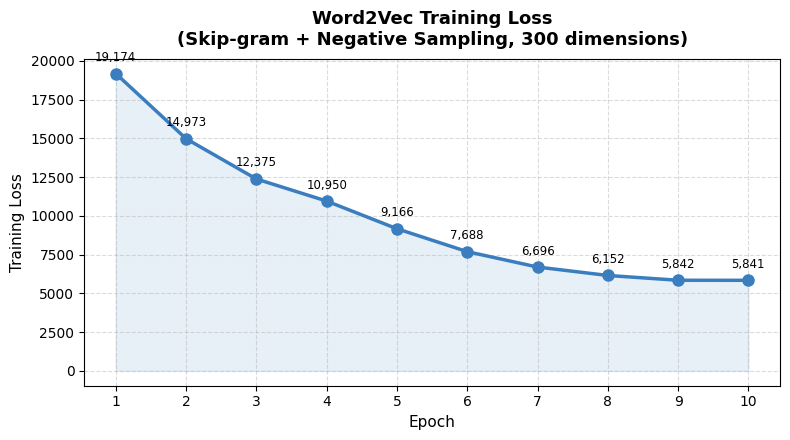

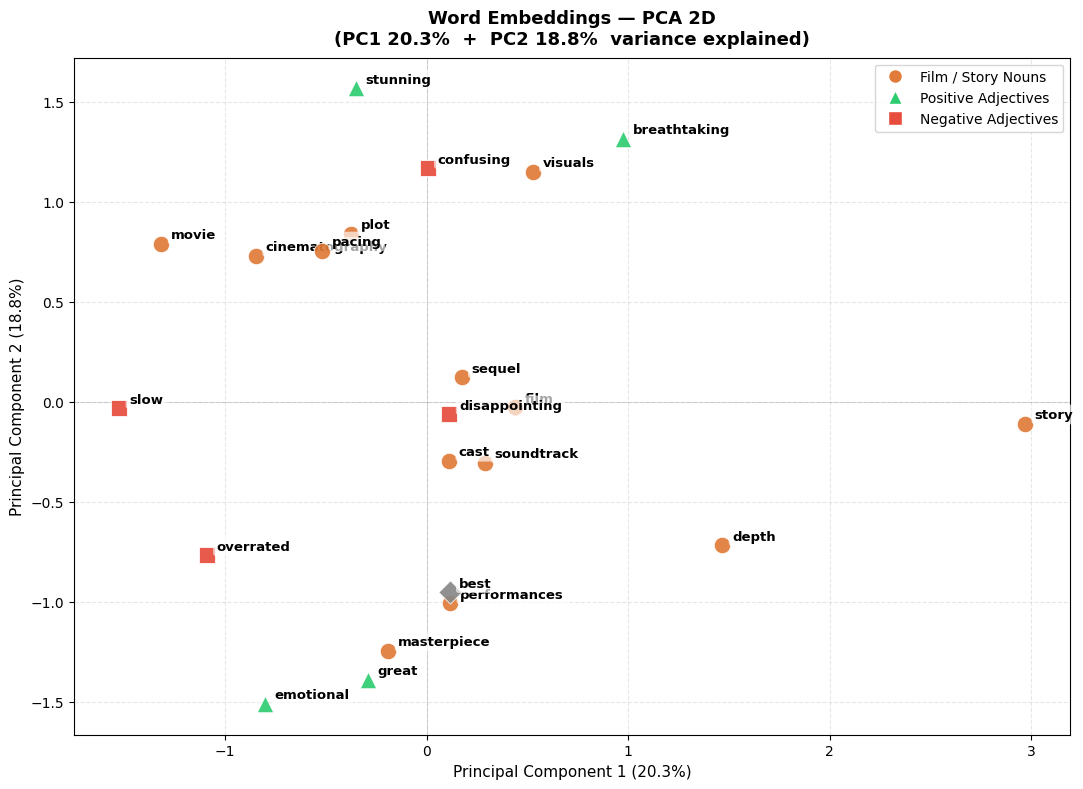

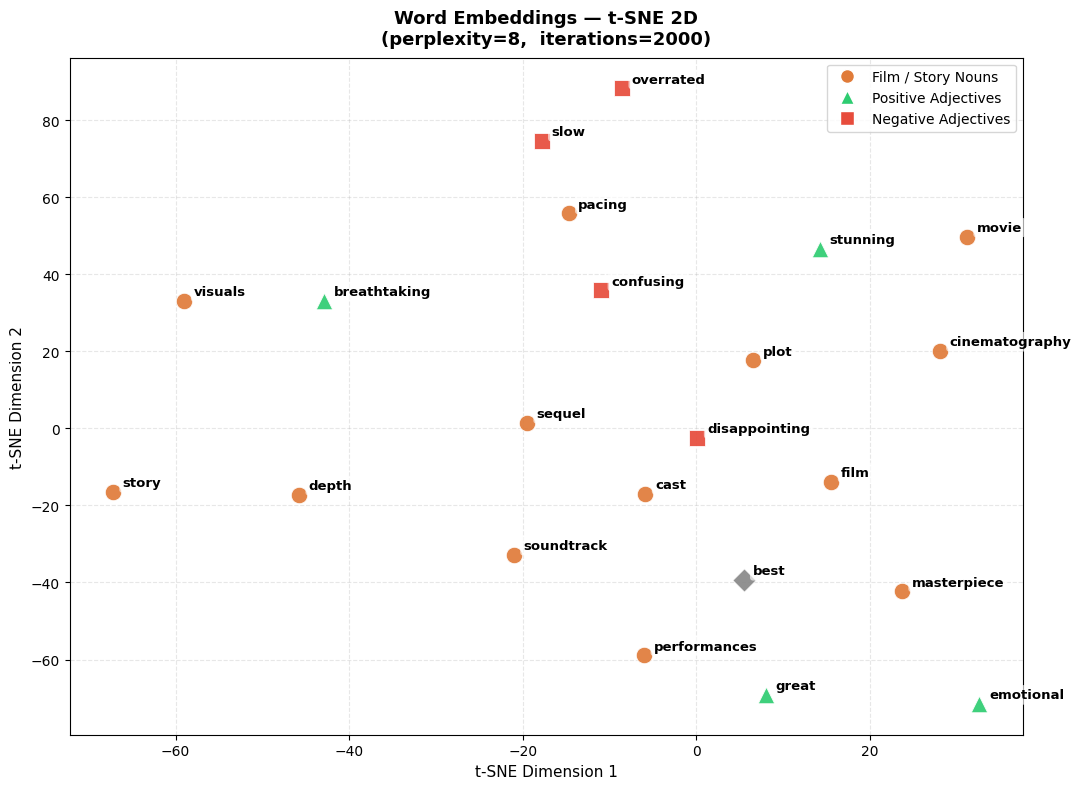

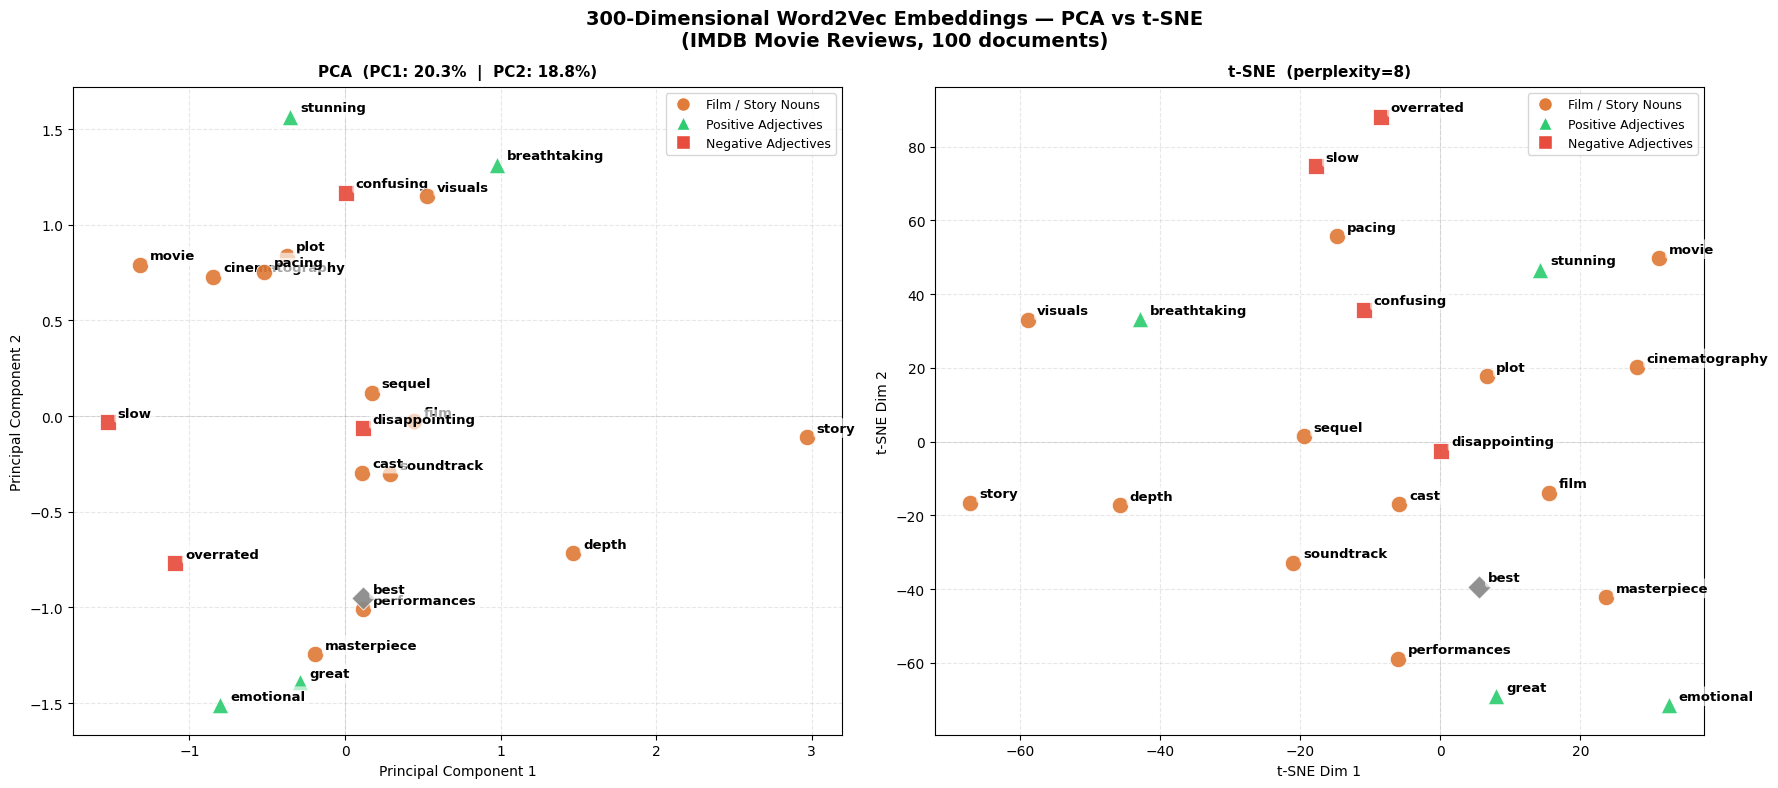


COSINE SIMILARITY BETWEEN WORD PAIRS
  Word 1                 Word 2                 Similarity   Interpretation
  ------------------------------------------------------------------------
  film                   movie                  0.3767       moderate
  story                  plot                   0.3433       moderate
  cinematography         visuals                0.4941       moderate
  great                  stunning               0.3498       moderate
  disappointing          overrated              0.3799       moderate
  slow                   best                   0.2202       moderate
  masterpiece            breathtaking           0.3543       moderate
  film                   slow                   0.3568       moderate


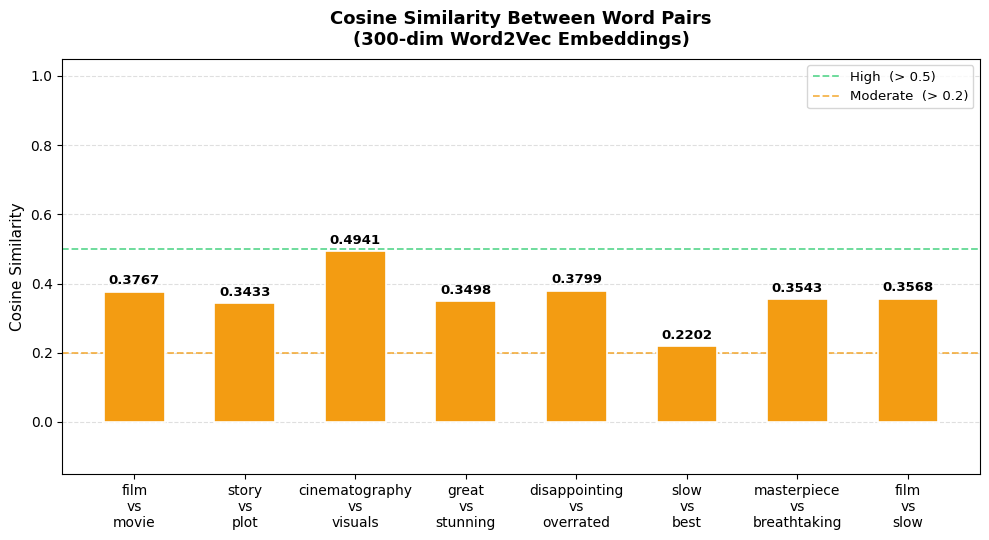

In [23]:
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

# ── Load data & build vocabulary ─────────────────────────────────────────────
df = pd.read_csv("/content/imdb_reviews_cleaned (1).csv").head(100)
texts = df["review_text"].fillna("").tolist()

def tokenize(text):
    return re.findall(r"[a-zA-Z']+", text.lower())

corpus = [tokenize(t) for t in texts]
vocab  = sorted(set(w for doc in corpus for w in doc))
w2i    = {w: i for i, w in enumerate(vocab)}
i2w    = {i: w for w, i in w2i.items()}
V      = len(vocab)
print(f"Vocabulary size : {V}")

# ── Build skip-gram training pairs (window = 2) ───────────────────────────────
pairs = []
for doc in corpus:
    indices = [w2i[w] for w in doc]
    for i, target in enumerate(indices):
        for j in range(max(0, i - 2), min(len(indices), i + 3)):
            if i != j:
                pairs.append((target, indices[j]))
print(f"Skip-gram pairs : {len(pairs)}")

# ── (1) Train 300-dimensional Word2Vec (Skip-gram + Negative Sampling) ────────
EMBED_DIM   = 300
LR          = 0.025
EPOCHS      = 10
NEG_SAMPLES = 5

random.seed(42)
np.random.seed(42)

W1 = (np.random.randn(V, EMBED_DIM) * 0.01).astype(np.float32)  # input embeddings
W2 = (np.random.randn(V, EMBED_DIM) * 0.01).astype(np.float32)  # output embeddings

# Unigram^0.75 distribution for negative sampling
freq_arr = np.array(
    [sum(1 for doc in corpus for w in doc if w == i2w[idx]) for idx in range(V)],
    dtype=np.float32,
)
freq_arr  = freq_arr ** 0.75
freq_arr /= freq_arr.sum()

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -10, 10)))

sample_pairs = random.sample(pairs, min(8000, len(pairs)))
epoch_losses = []

for epoch in range(EPOCHS):
    loss = 0.0
    for target_idx, ctx_idx in sample_pairs:
        v_t  = W1[target_idx]
        v_c  = W2[ctx_idx]
        s    = sigmoid(float(v_t @ v_c))
        # Positive update
        W2[ctx_idx] -= LR * (s - 1.0) * v_t
        grad          = (s - 1.0) * v_c
        loss         -= np.log(s + 1e-9)
        # Negative samples
        neg_idxs = np.random.choice(V, NEG_SAMPLES, p=freq_arr)
        for n_idx in neg_idxs:
            v_n  = W2[n_idx]
            s_n  = sigmoid(float(v_t @ v_n))
            W2[n_idx] -= LR * s_n * v_t
            grad      += s_n * v_n
            loss      -= np.log(1.0 - s_n + 1e-9)
        W1[target_idx] -= LR * grad
    epoch_losses.append(loss)
    print(f"  Epoch {epoch+1:>2}/{EPOCHS}   Loss: {loss:,.2f}")

embeddings = W1.copy()
print(f"\nEmbedding matrix : {embeddings.shape}  (words x dimensions)")

# ── Word list for visualisation (only words present in vocab) ─────────────────
CANDIDATES = [
    "film", "movie", "story", "plot", "cinematography", "pacing",
    "sequel", "soundtrack", "cast", "depth", "great", "confusing",
    "stunning", "slow", "disappointing", "emotional", "overrated",
    "masterpiece", "breathtaking", "performances", "visuals", "best",
]
target_words = [w for w in CANDIDATES if w in w2i]
word_vecs    = np.array([embeddings[w2i[w]] for w in target_words])
print(f"Words for plots  : {len(target_words)}  ->  {target_words}")

# Colour & marker per semantic group
FILM_NOUNS = {"film","movie","story","plot","cinematography","pacing","sequel",
              "soundtrack","cast","depth","masterpiece","performances","visuals"}
POS_ADJ    = {"great","stunning","breathtaking","emotional"}
NEG_ADJ    = {"confusing","slow","disappointing","overrated"}

def get_style(w):
    if w in FILM_NOUNS: return "#e07b39", "o"
    if w in POS_ADJ:    return "#2ecc71", "^"
    if w in NEG_ADJ:    return "#e74c3c", "s"
    return "#888888", "D"

colours = [get_style(w)[0] for w in target_words]
markers  = [get_style(w)[1] for w in target_words]

legend_handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#e07b39", markersize=10, label="Film / Story Nouns"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="#2ecc71", markersize=10, label="Positive Adjectives"),
    Line2D([0],[0], marker="s", color="w", markerfacecolor="#e74c3c", markersize=10, label="Negative Adjectives"),
]

def scatter_words(ax, coord, words, cols, mks):
    for i, (w, c, m) in enumerate(zip(words, cols, mks)):
        ax.scatter(coord[i,0], coord[i,1], c=c, marker=m, s=140,
                   alpha=0.92, zorder=3, edgecolors="white", linewidths=0.6)
        ax.annotate(w, (coord[i,0], coord[i,1]),
                    xytext=(7, 4), textcoords="offset points",
                    fontsize=9.5, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.65, ec="none"))

# ── Figure 1: Training Loss Curve ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, EPOCHS+1), epoch_losses, "o-", color="#3a7ebf", lw=2.5, ms=8, zorder=3)
ax.fill_between(range(1, EPOCHS+1), epoch_losses, alpha=0.12, color="#3a7ebf")
for e, l in zip(range(1, EPOCHS+1), epoch_losses):
    ax.annotate(f"{l:,.0f}", (e, l), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8.5)
ax.set_title("Word2Vec Training Loss\n(Skip-gram + Negative Sampling, 300 dimensions)",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Training Loss", fontsize=11)
ax.set_xticks(range(1, EPOCHS+1))
ax.grid(True, ls="--", alpha=0.45)
plt.tight_layout()
plt.show()

# ── Figure 2: PCA 2D ──────────────────────────────────────────────────────────
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(word_vecs)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(11, 8))
scatter_words(ax, coords, target_words, colours, markers)
ax.set_title(f"Word Embeddings — PCA 2D\n(PC1 {var1:.1f}%  +  PC2 {var2:.1f}%  variance explained)",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel(f"Principal Component 1 ({var1:.1f}%)", fontsize=11)
ax.set_ylabel(f"Principal Component 2 ({var2:.1f}%)", fontsize=11)
ax.axhline(0, color="gray", lw=0.5, alpha=0.4)
ax.axvline(0, color="gray", lw=0.5, alpha=0.4)
ax.grid(True, ls="--", alpha=0.3)
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
plt.show()

# ── Figure 3: t-SNE 2D ────────────────────────────────────────────────────────
tsne    = TSNE(n_components=2, perplexity=min(8, len(target_words)-1),
               random_state=42, max_iter=2000)
tcoords = tsne.fit_transform(word_vecs)

fig, ax = plt.subplots(figsize=(11, 8))
scatter_words(ax, tcoords, target_words, colours, markers)
ax.set_title("Word Embeddings — t-SNE 2D\n(perplexity=8,  iterations=2000)",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.grid(True, ls="--", alpha=0.3)
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
plt.show()

# ── Figure 4: Combined PCA + t-SNE side by side ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("300-Dimensional Word2Vec Embeddings — PCA vs t-SNE\n"
             "(IMDB Movie Reviews, 100 documents)",
             fontsize=14, fontweight="bold")
for ax_plot, coord, title, xl, yl in [
    (axes[0], coords,
     f"PCA  (PC1: {var1:.1f}%  |  PC2: {var2:.1f}%)",
     "Principal Component 1", "Principal Component 2"),
    (axes[1], tcoords,
     "t-SNE  (perplexity=8)",
     "t-SNE Dim 1", "t-SNE Dim 2"),
]:
    scatter_words(ax_plot, coord, target_words, colours, markers)
    ax_plot.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax_plot.set_xlabel(xl, fontsize=10)
    ax_plot.set_ylabel(yl, fontsize=10)
    ax_plot.grid(True, ls="--", alpha=0.3)
    ax_plot.axhline(0, color="gray", lw=0.4, alpha=0.35)
    ax_plot.axvline(0, color="gray", lw=0.4, alpha=0.35)
    ax_plot.legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.show()

# ── (3) Cosine similarity ─────────────────────────────────────────────────────
def cosine_sim(w1, w2):
    if w1 not in w2i or w2 not in w2i:
        return None
    v1, v2 = embeddings[w2i[w1]], embeddings[w2i[w2]]
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-9))

word_pairs = [
    ("film",          "movie"),
    ("story",         "plot"),
    ("cinematography","visuals"),
    ("great",         "stunning"),
    ("disappointing", "overrated"),
    ("slow",          "best"),
    ("masterpiece",   "breathtaking"),
    ("film",          "slow"),
]
# Keep only pairs where both words exist in vocab
word_pairs = [(w1, w2) for w1, w2 in word_pairs if w1 in w2i and w2 in w2i]
sims   = [cosine_sim(w1, w2) for w1, w2 in word_pairs]
labels = [f"{w1}\nvs\n{w2}" for w1, w2 in word_pairs]

# Print table
print("\n" + "=" * 60)
print("COSINE SIMILARITY BETWEEN WORD PAIRS")
print("=" * 60)
print(f"  {'Word 1':<22} {'Word 2':<22} {'Similarity':<12} Interpretation")
print("  " + "-" * 72)
for (w1, w2), s in zip(word_pairs, sims):
    tag = "high" if s > 0.5 else ("moderate" if s > 0.2 else "low")
    print(f"  {w1:<22} {w2:<22} {s:.4f}       {tag}")

# ── Figure 5: Cosine Similarity Bar Chart ─────────────────────────────────────
bar_cols = ["#2ecc71" if s > 0.5 else "#f39c12" if s > 0.2 else "#e74c3c" for s in sims]
fig, ax  = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(labels, sims, color=bar_cols, edgecolor="white",
              linewidth=1.2, width=0.55, zorder=3)
ax.axhline(0.5, color="#2ecc71", ls="--", lw=1.3, alpha=0.75, label="High  (> 0.5)")
ax.axhline(0.2, color="#f39c12", ls="--", lw=1.3, alpha=0.75, label="Moderate  (> 0.2)")
for bar, val in zip(bars, sims):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f"{val:.4f}", ha="center", va="bottom",
            fontsize=9.5, fontweight="bold")
ax.set_title("Cosine Similarity Between Word Pairs\n(300-dim Word2Vec Embeddings)",
             fontsize=13, fontweight="bold", pad=10)
ax.set_ylabel("Cosine Similarity", fontsize=11)
ax.set_ylim(-0.15, 1.05)
ax.grid(True, axis="y", ls="--", alpha=0.4, zorder=0)
ax.legend(fontsize=9.5)
plt.tight_layout()
plt.show()

## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [24]:
# The GitHub link of your final csv file
print("\n# GitHub link of final CSV file:")
print("https://github.com/VenkataAkashGurram/VenkataAkashGurram_INFO5731_Spring2026/blob/main/imdb_reviews_annotated.csv")



# GitHub link of final CSV file:
https://github.com/VenkataAkashGurram/VenkataAkashGurram_INFO5731_Spring2026/blob/main/imdb_reviews_annotated.csv


# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:
The most interesting part of the assignment was the N -gram analysis (Q1 ). This can be demonstrated by establishing frequency counts and conditional probabilities by building them out of the fundamental statistical language models.
The Word2Vec implementation Q3 was the most difficult. To be able to get the negative-sampling gradient gradient, it required a good deal of effort to work with matrix shapes and maintain numbers steady. To prevent overflow, we cut the sigmoid argument.
The TF‑IDF ranking in Q2 was fun. The theory is brought to reality by the fact that it displays useful search results at once.
The amount of time available was adequate to the functions. The scratch requirements of Q1 and Q2 did not make it too deep.